<a href="https://colab.research.google.com/github/zhong-david/zhong-david.github.io/blob/master/HW3_Q7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
#Here we load the wine dataset

import pandas as pd
import numpy as np


df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                      'machine-learning-databases/wine/wine.data',
                      header=None)

df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

# if the Wine dataset is temporarily unavailable from the
# UCI machine learning repository, un-comment the following line
# of code to load the dataset from a local path:

# df_wine = pd.read_csv('wine.data', header=None)

# drop 1 class
df_wine = df_wine[df_wine['Class label'] != 1]


#We will use two features for this binary classification problem.
y = df_wine['Class label'].values
X = df_wine[['Alcohol', 'OD280/OD315 of diluted wines']].values

In [35]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

#Define function that will let us plot decision regions
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

    # highlight test samples
    if test_idx:
        # plot all samples
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    c='',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100, 
                    label='test set')

Part a

In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


le = LabelEncoder()
y = le.fit_transform(y)




#split your data into a training set and test set using random_state=1, a test size of 20% with stratification.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify = y)


Part b-c

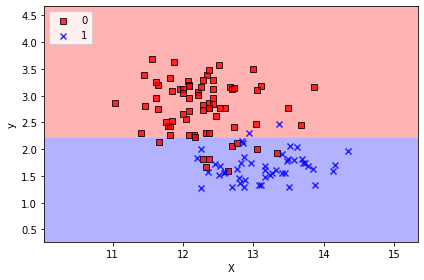

0.875

In [38]:
#import DecisionTreeClassifier, AdaBoostClassifier, and accuracy_score from sklearn.
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score


#fit a decision tree classifier and adaboost classifier, then compare their training and test set accuracies.

#### TREE ####
tree = DecisionTreeClassifier(criterion='entropy',max_depth=1,random_state = 1)
tree.fit(X_train, y_train)
X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X_combined, y_combined, 
                      classifier=tree)

plt.xlabel('X')
plt.ylabel('y')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
y_pred = tree.predict(X_test)
accuracy_score(y_test, y_pred) #print accuracy score

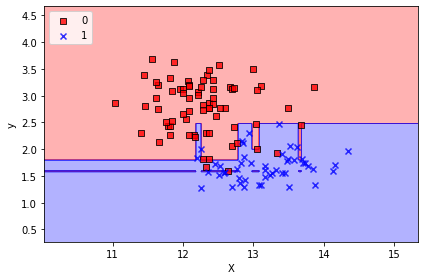

0.9166666666666666

In [26]:
### boost_classifier ###
boost_classifier = AdaBoostClassifier(n_estimators=500,learning_rate=0.1)
boost_classifier.fit(X_train,y_train)
X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X_combined, y_combined, 
                      classifier=boost_classifier)

plt.xlabel('X')
plt.ylabel('y')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
y_pred = boost_classifier.predict(X_test)
accuracy_score(y_test, y_pred) #print accuracy score

Part d

Fitting 5 folds for each of 2000 candidates, totalling 10000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done 1030 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   13.7s finished


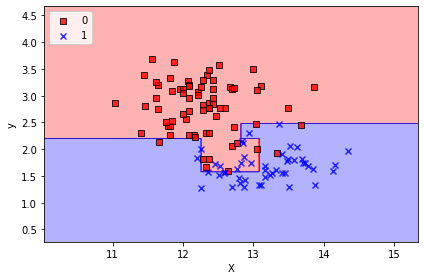

0.7916666666666666

In [39]:
#Repeat part b-c, but now use GridSearchCV with 5-fold cross-validation to optimize hyperparameters for the DecisionTreeClassifier and AdaBoostClassifier.

from sklearn.model_selection import GridSearchCV  #good to search optimal hyperparameters
params = {'max_leaf_nodes': list(range(0, 100)), 'min_samples_split': [1, 2, 3, 4, 5], 'max_depth': [1, 2, 3, 4]} # create list of params for grid search cv
tree1 = GridSearchCV(DecisionTreeClassifier(criterion='entropy', random_state=1), params, n_jobs=-1, verbose=1, cv=5) # create list of params for grid search cv. do 5 fold CV

tree1.fit(X_train, y_train) #fit the model from grid-search CV

X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X_combined, y_combined, 
                      classifier=tree1)

plt.xlabel('X')
plt.ylabel('y')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
y_pred = tree1.predict(X_test)
accuracy_score(y_test, y_pred) #print accuracy score

In [23]:
params = {'n_estimators': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600], 'learning_rate':[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]} # create list of params for grid search cv
boost_classifier2 = GridSearchCV(AdaBoostClassifier(), params, n_jobs=-1, verbose=1, cv=5) # create list of params for grid search cv. do 5 fold CV

boost_classifier2.fit(X_train, y_train) #fit the model from grid-search CV

Fitting 5 folds for each of 120 candidates, totalling 600 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  62 tasks      | elapsed:   22.8s
[Parallel(n_jobs=-1)]: Done 212 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 462 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 600 out of 600 | elapsed:  3.8min finished


GridSearchCV(cv=5, error_score=nan,
             estimator=AdaBoostClassifier(algorithm='SAMME.R',
                                          base_estimator=None,
                                          learning_rate=1.0, n_estimators=50,
                                          random_state=None),
             iid='deprecated', n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7,
                                           0.8, 0.9, 1],
                         'n_estimators': [50, 100, 150, 200, 250, 300, 350, 400,
                                          450, 500, 550, 600]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=1)

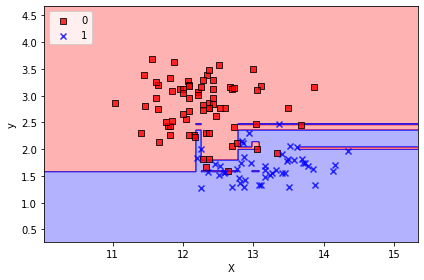

0.9166666666666666

In [30]:
X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X_combined, y_combined, 
                      classifier=boost_classifier2)

plt.xlabel('X')
plt.ylabel('y')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
y_pred = boost_classifier2.predict(X_test)
accuracy_score(y_test, y_pred) #print accuracy score